# Stroke Risk Prediction: Initial Data Exploration

This notebook explores the structure, quality, and characteristics of the stroke risk prediction dataset.

### Data Attribution

This analysis uses the *Stroke Risk Prediction Dataset* created and uploaded to Kaggle by Mobeen Fatimah. The dataset is synthetically generated for educational, research, and machine-learning purposes and is licensed under **CC BY-SA 4.0**.

Source: [Kaggle — Stroke Risk Prediction Dataset](https://www.kaggle.com/datasets/mobeenfatimah/stroke-risk-prediction-dataset?utm_source=chatgpt.com)
License: [Creative Commons Attribution-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-sa/4.0/?utm_source=chatgpt.com)

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import xgboost as xg

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

df = pd.read_csv("../data/raw/stroke_risk_prediction_dataset.csv")

df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Blood_Glucose,HbA1c,Total_Cholesterol,HDL,LDL,Triglycerides,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Hours,Stress_Level,Diet_Quality,Family_History_Stroke,Family_History_Heart_Disease,Diabetes,Hypertension,Heart_Disease,Previous_TIA,Atrial_Fibrillation,Chronic_Kidney_Disease,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Stroke_Risk
0,1,80.0,Male,China,145.2,69.3,32.9,112,82,109,132.2,5.2,300.1,50.9,199.6,185.0,Former,Occasionally,Moderate,7.6,High,Healthy,No,No,No,No,No,No,No,No,Excellent,NaN,79.0,Retired,Urban,High,47,Exercise Regularly,Yes,Moderate
1,2,37.0,Female,United Kingdom,188.6,110.8,31.1,137,76,59,187.5,7.1,156.4,55.1,NaN,131.3,Current,Occasionally,High,7.3,Low,Poor,No,No,No,No,No,No,No,Yes,Average,0.6,48.0,Student,Rural,Medium,40,Improve Diet Quality,Yes,Moderate
2,3,85.0,Female,Germany,175.5,103.7,33.7,108,105,89,196.4,8.0,232.0,62.2,200.2,65.7,Former,Never,Low,6.3,High,Average,No,Yes,No,Yes,No,No,No,No,Poor,1.7,114.0,Private,Rural,Medium,76,Monitor Blood Glucose Daily,Yes,High
3,4,44.0,Other,Brazil,161.3,50.2,19.3,126,73,88,209.1,7.3,215.1,50.8,163.3,315.6,Never,Occasionally,High,9.9,Low,Healthy,No,No,No,No,No,No,No,Yes,Poor,1.5,101.0,Retired,Rural,Low,40,Exercise Regularly,Yes,Moderate
4,5,52.0,Female,United States,162.8,103.6,39.1,115,60,70,88.6,7.1,140.7,40.5,137.9,151.2,Never,Frequently,Moderate,9.4,High,Poor,Yes,No,No,No,No,No,No,No,Average,7.1,55.0,Government,Rural,Medium,38,Monitor Blood Pressure,Yes,Moderate


## 1. Dataset Overview

Before conducting any analysis, we will examine the dataset's structure, variables, data types, missingness, and outcome distribution.

In [2]:
df.shape

(50000, 40)

In [3]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg',
       'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Heart_Rate', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 'HDL',
       'LDL', 'Triglycerides', 'Smoking_Status', 'Alcohol_Consumption',
       'Physical_Activity_Level', 'Sleep_Hours', 'Stress_Level',
       'Diet_Quality', 'Family_History_Stroke', 'Family_History_Heart_Disease',
       'Diabetes', 'Hypertension', 'Heart_Disease', 'Previous_TIA',
       'Atrial_Fibrillation', 'Chronic_Kidney_Disease', 'Medication_Adherence',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Work_Type',
       'Residence_Type', 'Air_Pollution_Exposure', 'Stroke_Risk_Score',
       'AI_Health_Recommendation', 'Doctor_Consultation_Needed',
       'Stroke_Risk'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    50000 non-null  int64  
 1   Age                           49781 non-null  float64
 2   Gender                        50000 non-null  str    
 3   Country                       50000 non-null  str    
 4   Height_cm                     48475 non-null  float64
 5   Weight_kg                     48477 non-null  float64
 6   BMI                           50000 non-null  float64
 7   Blood_Pressure_Systolic       50000 non-null  int64  
 8   Blood_Pressure_Diastolic      50000 non-null  int64  
 9   Heart_Rate                    50000 non-null  int64  
 10  Blood_Glucose                 49040 non-null  float64
 11  HbA1c                         48994 non-null  float64
 12  Total_Cholesterol             48996 non-null  float64
 13  HDL         

In [40]:
df.isna().sum().sort_values(ascending=False)

Height_cm                       1525
Weight_kg                       1523
Exercise_Hours_Per_Week         1054
Medication_Adherence            1051
Daily_Walking_Minutes           1051
LDL                             1050
Triglycerides                   1032
Sleep_Hours                     1026
HDL                             1021
HbA1c                           1006
Total_Cholesterol               1004
Blood_Glucose                    960
Age                              219
Patient_ID                         0
Gender                             0
Country                            0
Blood_Pressure_Systolic            0
BMI                                0
Heart_Rate                         0
Physical_Activity_Level            0
Stress_Level                       0
Smoking_Status                     0
Alcohol_Consumption                0
Blood_Pressure_Diastolic           0
Family_History_Heart_Disease       0
Family_History_Stroke              0
Diet_Quality                       0
D

In [41]:
missing_by_risk = pd.DataFrame({
    col: df.groupby("Stroke_Risk")[col].apply(lambda x: x.isna().mean() * 100)
    for col in df.columns
})

missing_by_risk

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Blood_Glucose,HbA1c,Total_Cholesterol,HDL,LDL,Triglycerides,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Hours,Stress_Level,Diet_Quality,Family_History_Stroke,Family_History_Heart_Disease,Diabetes,Hypertension,Heart_Disease,Previous_TIA,Atrial_Fibrillation,Chronic_Kidney_Disease,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Stroke_Risk
Stroke_Risk,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
High,0.0,0.421070,0.0,0.0,3.104359,2.939234,0.0,0.0,0.0,0.0,1.882431,1.874174,2.014531,2.270476,2.064069,2.072325,0.0,0.0,0.0,2.031044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.031044,2.220938,1.981506,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Low,0.0,0.512383,0.0,0.0,2.618844,3.444350,0.0,0.0,0.0,0.0,2.134927,1.793339,1.964133,1.907202,1.565613,1.594079,0.0,0.0,0.0,2.248790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.163393,2.334187,2.419584,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Moderate,0.0,0.436364,0.0,0.0,3.074909,3.042909,0.0,0.0,0.0,0.0,1.911273,2.082909,2.010182,1.975273,2.167273,2.109091,0.0,0.0,0.0,2.039273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.120727,2.045091,2.112000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Blood_Glucose,HbA1c,Total_Cholesterol,HDL,LDL,Triglycerides,Sleep_Hours,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Stroke_Risk_Score
count,50000.000000,49781.000000,48475.000000,48477.000000,50000.000000,50000.000000,50000.000000,50000.000000,49040.000000,48994.000000,48996.000000,48979.000000,48950.000000,48968.000000,48974.000000,48946.000000,48949.000000,50000.000000
mean,25000.500000,53.903096,170.125582,87.506141,30.901386,135.061420,84.840620,82.521020,145.031421,7.488103,225.020832,57.661655,140.149685,205.200147,7.005401,5.001214,59.947742,54.782320
std,14433.901067,21.070953,14.484573,24.565490,10.254560,20.526562,14.685149,16.141082,43.405484,1.733379,54.776297,18.718465,46.146752,83.538912,1.731441,2.892267,34.987073,13.996729
min,1.000000,18.000000,145.000000,45.000000,11.900000,100.000000,60.000000,55.000000,70.000000,4.500000,130.000000,25.000000,60.000000,60.000000,4.000000,0.000000,0.000000,2.000000
25%,12500.750000,36.000000,157.600000,66.200000,22.700000,117.000000,72.000000,68.000000,107.400000,6.000000,177.700000,41.500000,100.100000,133.200000,5.500000,2.500000,30.000000,45.000000
50%,25000.500000,54.000000,170.100000,87.500000,30.100000,135.000000,85.000000,83.000000,145.100000,7.500000,224.900000,57.700000,140.200000,205.300000,7.000000,5.000000,60.000000,54.000000
75%,37500.250000,72.000000,182.800000,108.800000,37.800000,153.000000,98.000000,97.000000,182.700000,9.000000,272.400000,73.800000,180.000000,277.600000,8.500000,7.500000,90.000000,64.000000
max,50000.000000,90.000000,195.000000,130.000000,61.500000,170.000000,110.000000,110.000000,220.000000,10.500000,320.000000,90.000000,220.000000,350.000000,10.000000,10.000000,120.000000,100.000000


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49781.0,53.903096,21.070953,18.0,36.00,54.0,72.00,90.0
Height_cm,48475.0,170.125582,14.484573,145.0,157.60,170.1,182.80,195.0
Weight_kg,48477.0,87.506141,24.565490,45.0,66.20,87.5,108.80,130.0
BMI,50000.0,30.901386,10.254560,11.9,22.70,30.1,37.80,61.5
Blood_Pressure_Systolic,50000.0,135.061420,20.526562,100.0,117.00,135.0,153.00,170.0
Blood_Pressure_Diastolic,50000.0,84.840620,14.685149,60.0,72.00,85.0,98.00,110.0
Heart_Rate,50000.0,82.521020,16.141082,55.0,68.00,83.0,97.00,110.0
Blood_Glucose,49040.0,145.031421,43.405484,70.0,107.40,145.1,182.70,220.0
HbA1c,48994.0,7.488103,1.733379,4.5,6.00,7.5,9.00,10.5


In [38]:
categorical_cols = df.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Other     16791
Male      16768
Female    16441
Name: count, dtype: int64

Country:
Country
Italy             2058
Singapore         2047
India             2041
Bangladesh        2040
Pakistan          2037
Indonesia         2029
South Africa      2027
Mexico            2021
Turkey            2019
France            2015
Brazil            2012
Canada            2006
Russia            2002
Australia         1999
Saudi Arabia      1991
Germany           1990
United States     1985
South Korea       1985
United Kingdom    1983
Malaysia          1976
Japan             1974
China             1948
Spain             1944
UAE               1938
Nigeria           1933
Name: count, dtype: int64

Smoking_Status:
Smoking_Status
Never      16779
Current    16718
Former     16503
Name: count, dtype: int64

Alcohol_Consumption:
Alcohol_Consumption
Occasionally    16726
Frequently      16669
Never           16605
Name: count, dtype: int64

Physical_Activity_Level:
Physical_Activity_Leve

The Stroke Risk Analysis dataset contains 50,000 rows and 40 columns of patient data. Variables in the dataset include patient demographics, health data, and clinical recommendations (e.g., need for consultation with a doctor, AI recommendation based on health profile, stroke risk score). There are missing values throughout the dataset. There are no duplicate records in the dataset.

`Stroke_Risk` appears to be the target variable in this dataset. We next need to investigate the `Stroke_Risk` and `Stroke_Risk_Score` variables to identify their relationship and examine whether `Stroke_Risk_Score` should be included among other variables as a predictor of `Stroke_Risk`.


In [18]:
df["Stroke_Risk"].value_counts()

Stroke_Risk
Moderate    34375
High        12112
Low          3513
Name: count, dtype: int64

In [19]:
df["Stroke_Risk"].value_counts(normalize=True)

Stroke_Risk
Moderate    0.68750
High        0.24224
Low         0.07026
Name: proportion, dtype: float64

In [20]:
df.groupby("Stroke_Risk")["Stroke_Risk_Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Stroke_Risk,,,,,,,,
High,12112.0,73.134082,7.085499,65.0,68.0,71.0,77.0,100.0
Low,3513.0,28.836892,4.779582,2.0,26.0,30.0,33.0,34.0
Moderate,34375.0,50.967622,7.932104,35.0,45.0,51.0,58.0,64.0


<Axes: title={'center': 'Stroke_Risk_Score'}, xlabel='Stroke_Risk'>

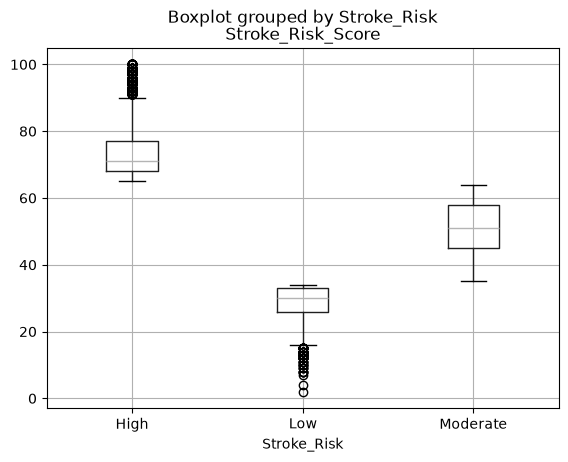

In [21]:
df.boxplot(column="Stroke_Risk_Score", by="Stroke_Risk")

Exploration indicates that `Stroke_Risk` is deterministically derived from `Stroke_Risk_Score`. In this dataset, scores from 2–34 correspond to Low risk, scores from 35–64 correspond to Moderate risk, and scores from 65–100 correspond to High risk. Applying these thresholds to `Stroke_Risk_Score` reproduced the recorded `Stroke_Risk` classification for 100% of observations.

Because `Stroke_Risk` can be perfectly determined from `Stroke_Risk_Score`, the score will be excluded from predictive modeling as a potential source of target leakage. The machine-learning analysis will instead investigate whether the observed risk classification can be predicted from the underlying demographic, physiological, behavioral, and health-related characteristics.

`Doctor_Consultation_Needed` and `AI_Health_Recommendation` appear to be downstream variables. Next, we will examine whether these variables differ deterministically by `Stroke_Risk`.

In [24]:
pd.crosstab(
    df["Stroke_Risk"],
    df["Doctor_Consultation_Needed"],
    normalize="index"
)

Doctor_Consultation_Needed,No,Yes
Stroke_Risk,,
High,0.000000,1.000000
Low,0.900655,0.099345
Moderate,0.298385,0.701615


In [25]:
pd.crosstab(
    df["Stroke_Risk"],
    df["AI_Health_Recommendation"],
    normalize="index"
)

AI_Health_Recommendation,Annual Health Checkup,Balanced Diet,Consult Neurologist Immediately,Continue Regular Exercise,Emergency Cardiovascular Assessment,Exercise Regularly,Healthy Lifestyle,Improve Diet Quality,Maintain Healthy Weight,Monitor Blood Glucose Daily,Monitor Blood Pressure,Reduce Sodium Intake,Strict Blood Pressure Control
Stroke_Risk,,,,,,,,,,,,,
High,0.000000,0.000000,0.245872,0.000000,0.255614,0.000000,0.00000,0.000000,0.00000,0.248266,0.000000,0.000000,0.250248
Low,0.196413,0.203814,0.000000,0.201822,0.000000,0.000000,0.20296,0.000000,0.19499,0.000000,0.000000,0.000000,0.000000
Moderate,0.000000,0.000000,0.000000,0.000000,0.000000,0.249745,0.00000,0.248262,0.00000,0.000000,0.251636,0.250356,0.000000


We find that the recommendations reflected in `AI_Health_Recommendation` vary categorically by `Stroke_Risk`, and the recommendations for doctor consulations in `Doctor_Consultation_Needed` are highly correlated with `Stroke_Risk` categories. These variables will be considered downstream from `Stroke_Risk` for the purposes of subsequent analyses.

### Creating the Modeling Dataset

In [42]:
# Variables that should not be used as predictors
excluded_columns = [
    "Patient_ID",
    "Stroke_Risk_Score",
    "AI_Health_Recommendation",
    "Doctor_Consultation_Needed"
]

# Create a copy containing all remaining variables
model_df = df.drop(columns=excluded_columns).copy()

model_df.head()

,Age,Gender,Country,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Blood_Glucose,HbA1c,Total_Cholesterol,HDL,LDL,Triglycerides,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Sleep_Hours,Stress_Level,Diet_Quality,Family_History_Stroke,Family_History_Heart_Disease,Diabetes,Hypertension,Heart_Disease,Previous_TIA,Atrial_Fibrillation,Chronic_Kidney_Disease,Medication_Adherence,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Work_Type,Residence_Type,Air_Pollution_Exposure,Stroke_Risk
0,80.0,Male,China,145.2,69.3,32.9,112,82,109,132.2,5.2,300.1,50.9,199.6,185.0,Former,Occasionally,Moderate,7.6,High,Healthy,No,No,No,No,No,No,No,No,Excellent,NaN,79.0,Retired,Urban,High,Moderate
1,37.0,Female,United Kingdom,188.6,110.8,31.1,137,76,59,187.5,7.1,156.4,55.1,NaN,131.3,Current,Occasionally,High,7.3,Low,Poor,No,No,No,No,No,No,No,Yes,Average,0.6,48.0,Student,Rural,Medium,Moderate
2,85.0,Female,Germany,175.5,103.7,33.7,108,105,89,196.4,8.0,232.0,62.2,200.2,65.7,Former,Never,Low,6.3,High,Average,No,Yes,No,Yes,No,No,No,No,Poor,1.7,114.0,Private,Rural,Medium,High
3,44.0,Other,Brazil,161.3,50.2,19.3,126,73,88,209.1,7.3,215.1,50.8,163.3,315.6,Never,Occasionally,High,9.9,Low,Healthy,No,No,No,No,No,No,No,Yes,Poor,1.5,101.0,Retired,Rural,Low,Moderate
4,52.0,Female,United States,162.8,103.6,39.1,115,60,70,88.6,7.1,140.7,40.5,137.9,151.2,Never,Frequently,Moderate,9.4,High,Poor,Yes,No,No,No,No,No,No,No,Average,7.1,55.0,Government,Rural,Medium,Moderate


In [43]:
x = model_df.drop(columns="Stroke_Risk")
y = model_df["Stroke_Risk"]

print("Predictors:", x.shape)
print("Target:", y.shape)

Predictors: (50000, 35)
Target: (50000,)


In [52]:
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(x_train))
print("Testing observations:", len(x_test))

Training observations: 40000
Testing observations: 10000


In [53]:
numeric_features = x.select_dtypes(include="number").columns.tolist()
categorical_features = x.select_dtypes(include="str").columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Heart_Rate', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Sleep_Hours', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes']

Categorical features:
['Gender', 'Country', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Stress_Level', 'Diet_Quality', 'Family_History_Stroke', 'Family_History_Heart_Disease', 'Diabetes', 'Hypertension', 'Heart_Disease', 'Previous_TIA', 'Atrial_Fibrillation', 'Chronic_Kidney_Disease', 'Medication_Adherence', 'Work_Type', 'Residence_Type', 'Air_Pollution_Exposure']


In [55]:
numeric_pipeline = sk.pipeline.Pipeline([
    ("imputer", sk.impute.SimpleImputer(strategy="median")),
    ("scaler", sk.preprocessing.StandardScaler())
])

categorical_pipeline = sk.pipeline.Pipeline([
    ("imputer", sk.impute.SimpleImputer(strategy="most_frequent")),
    ("encoder", sk.preprocessing.OneHotEncoder(handle_unknown="ignore"))
])

In [56]:
preprocessor = sk.compose.ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [57]:
x_train_processed = preprocessor.fit_transform(x_train)

print("Original training shape:", x_train.shape)
print("Processed training shape:", x_train_processed.shape)

Original training shape: (40000, 35)
Processed training shape: (40000, 88)


In [59]:
print("Missing values:", np.isnan(x_train_processed).sum())

Missing values: 0


### Multinomial Logistic Regression

In [62]:
logistic_model = sk.linear_model.LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(x_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [63]:
x_test_processed = preprocessor.transform(x_test)

print("Processed test shape:", x_test_processed.shape)

Processed test shape: (10000, 88)


In [64]:
y_pred = logistic_model.predict(x_test_processed)

In [65]:
print(sklearn.metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.83      0.77      0.80      2422
         Low       0.78      0.59      0.67       703
    Moderate       0.88      0.93      0.90      6875

    accuracy                           0.86     10000
   macro avg       0.83      0.76      0.79     10000
weighted avg       0.86      0.86      0.86     10000



In [67]:
balanced_accuracy = sk.metrics.balanced_accuracy_score(y_test, y_pred)

print(f"Balanced accuracy: {balanced_accuracy:.3f}")

Balanced accuracy: 0.762


In [69]:
confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Moderate", "High"]
)

confusion_matrix

array([[ 415,  288,    0],
       [ 118, 6365,  392],
       [   0,  557, 1865]])

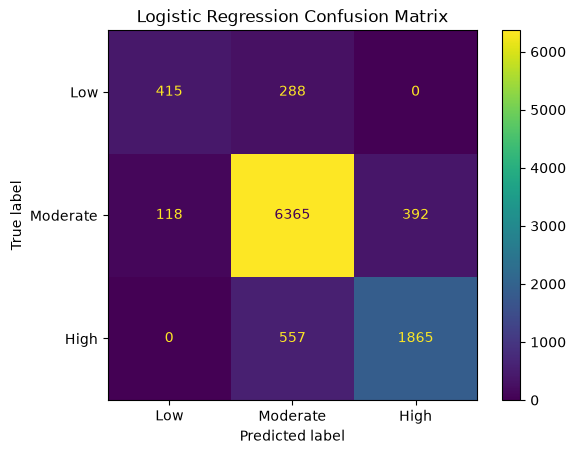

In [70]:
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

The multinomial logistic regression model achieved the following:
- Accuracy: 86%
- Balanced accuracy: 76.2%
- Macro F1: 0.79
- Weighted F1: 0.86

The model correctly identifies 59% of low risk cases, 93% of moderate risk cases, and 77% of high risk cases, with issues discrimintating between low-moderate and moderate-high risk cases.

### Random Forest

In [ ]:
# Create 300 decision trees with the seed 42 to set up our random forest
random_forest = sk.ensemble.RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [72]:
random_forest.fit(x_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [73]:
rf_pred = random_forest.predict(x_test_processed)

In [75]:
rf_accuracy = sk.metrics.accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = sklearn.metrics.balanced_accuracy_score(y_test, rf_pred)
rf_report = sklearn.metrics.classification_report(y_test, rf_pred)

print(f"Accuracy: {rf_accuracy:.3f}")
print(f"Balanced accuracy: {rf_balanced_accuracy:.3f}")
print()
print(rf_report)

Accuracy: 0.809
Balanced accuracy: 0.533

              precision    recall  f1-score   support

        High       0.93      0.51      0.66      2422
         Low       1.00      0.10      0.18       703
    Moderate       0.79      0.99      0.88      6875

    accuracy                           0.81     10000
   macro avg       0.91      0.53      0.57     10000
weighted avg       0.84      0.81      0.78     10000



In [76]:
rf_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Moderate", "High"]
)

print(rf_confusion_matrix)

[[  70  633    0]
 [   0 6785   90]
 [   0 1184 1238]]


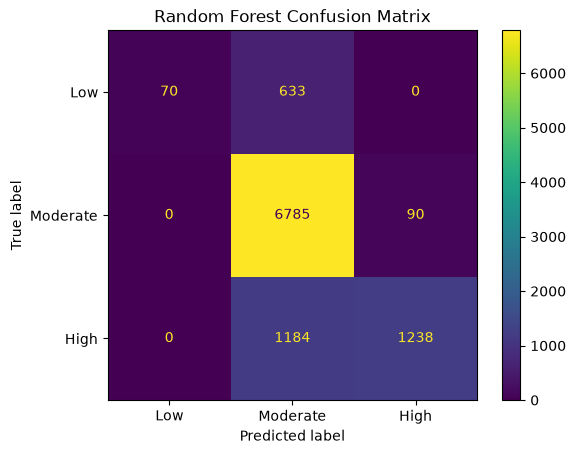

In [77]:
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Weighted Random Forest

The random forest model is conservative when predicting Low and High risk outcomes, and performed worse than the logistic regression model. This bias may be due to the smaller number of Low and High Risk cases relative to Moderate Risk cases in the training data. To test this hypothesis, balanced class weights will be applied to the model.

In [78]:
random_forest_weighted = sk.ensemble.RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [79]:
random_forest_weighted.fit(x_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [80]:
rf_weighted_pred = random_forest_weighted.predict(x_test_processed)

In [81]:
rf_weighted_accuracy = sk.metrics.accuracy_score(
    y_test,
    rf_weighted_pred
)

rf_weighted_balanced_accuracy = sk.metrics.balanced_accuracy_score(
    y_test,
    rf_weighted_pred
)

print(f"Accuracy: {rf_weighted_accuracy:.3f}")
print(f"Balanced accuracy: {rf_weighted_balanced_accuracy:.3f}")
print()
print(
    sk.metrics.classification_report(
        y_test,
        rf_weighted_pred
    )
)

Accuracy: 0.866
Balanced accuracy: 0.737

              precision    recall  f1-score   support

        High       0.81      0.79      0.80      2422
         Low       0.94      0.49      0.64       703
    Moderate       0.88      0.93      0.91      6875

    accuracy                           0.87     10000
   macro avg       0.88      0.74      0.78     10000
weighted avg       0.87      0.87      0.86     10000



In [82]:
rf_weighted_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    rf_weighted_pred,
    labels=["Low", "Moderate", "High"]
)

print(rf_weighted_confusion_matrix)

[[ 345  358    0]
 [  23 6406  446]
 [   0  514 1908]]


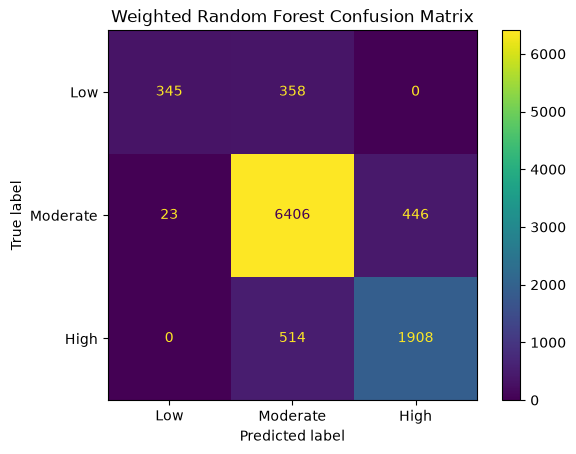

In [83]:
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=rf_weighted_confusion_matrix,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Weighted Random Forest Confusion Matrix")
plt.show()

Although class weights improved the accuracy of the random forest model by improving minority class performance, it still did not outperform the logistic regression model:
| Model                  |  Accuracy | Balanced Accuracy |  Macro F1 |
| ---------------------- | --------: | ----------------: | --------: |
| Logistic Regression    | **0.860** |         **0.762** | **0.790** |
| Weighted Random Forest |     0.866 |             0.737 |     0.783 |
| Random Forest          |     0.809 |             0.533 |     0.570 |

Next, we will apply the following hyperparameters and cross-validate each configuration using 5-fold stratified cross validation:
- Number of estimators
- Maximum depth
- Minimum number of samples required to be at a leaf node


In [85]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": ["balanced"]
}

In [86]:
grid_search = sk.model_selection.GridSearchCV(
    estimator=sk.ensemble.RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train_processed, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metri

In [87]:
print("Best parameters:")
print(grid_search.best_params_)

print()
print(f"Best cross-validation balanced accuracy: "
      f"{grid_search.best_score_:.3f}")

Best parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 300}

Best cross-validation balanced accuracy: 0.857


In [88]:
results = sk.model_selection.cross_validate(
    grid_search.best_estimator_,
    x_train_processed,
    y_train,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy"
)

print(results["test_score"])

[0.85275159 0.85948738 0.86440615 0.85478677 0.85404681]


In [89]:
tuned_random_forest = grid_search.best_estimator_

In [90]:
tuned_rf_pred = tuned_random_forest.predict(x_test_processed)

In [91]:
tuned_rf_accuracy = sk.metrics.accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_balanced_accuracy = sk.metrics.balanced_accuracy_score(
    y_test,
    tuned_rf_pred
)

print(f"Accuracy: {tuned_rf_accuracy:.3f}")
print(f"Balanced accuracy: {tuned_rf_balanced_accuracy:.3f}")
print()
print(
    sk.metrics.classification_report(
        y_test,
        tuned_rf_pred
    )
)

Accuracy: 0.753
Balanced accuracy: 0.849

              precision    recall  f1-score   support

        High       0.63      0.93      0.75      2422
         Low       0.41      0.95      0.57       703
    Moderate       0.96      0.67      0.79      6875

    accuracy                           0.75     10000
   macro avg       0.67      0.85      0.70     10000
weighted avg       0.84      0.75      0.76     10000



In [92]:
tuned_rf_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    tuned_rf_pred,
    labels=["Low", "Moderate", "High"]
)

print(tuned_rf_confusion_matrix)

[[ 667   36    0]
 [ 960 4620 1295]
 [   0  180 2242]]


The hyperparameterized weighted random forest model predicts the synthetic dataset's assigned stroke-risk category with 84.9% balanced accuracy. Instead of under-predicting low and high risk cases, the true positive rate (i.e., recall) of the updated model is 95% and 93% for these outcomes, respectively, while the recall of moderate risk cases has dropped from 93% to 67%.

In [95]:
tuned_rf_probabilities = tuned_random_forest.predict_proba(
    x_test_processed
)

print(tuned_rf_probabilities[:10])
print(tuned_random_forest.classes_)

[[0.07690486 0.5819903  0.34110484]
 [0.12564175 0.50735744 0.36700082]
 [0.45483577 0.10747549 0.43768874]
 [0.48463694 0.09946375 0.41589931]
 [0.53864785 0.07066596 0.39068619]
 [0.63786697 0.06305759 0.29907544]
 [0.14328277 0.44640981 0.41030743]
 [0.4910428  0.0872303  0.4217269 ]
 [0.51967872 0.11737278 0.36294849]
 [0.6368366  0.05408965 0.30907375]]
['High' 'Low' 'Moderate']


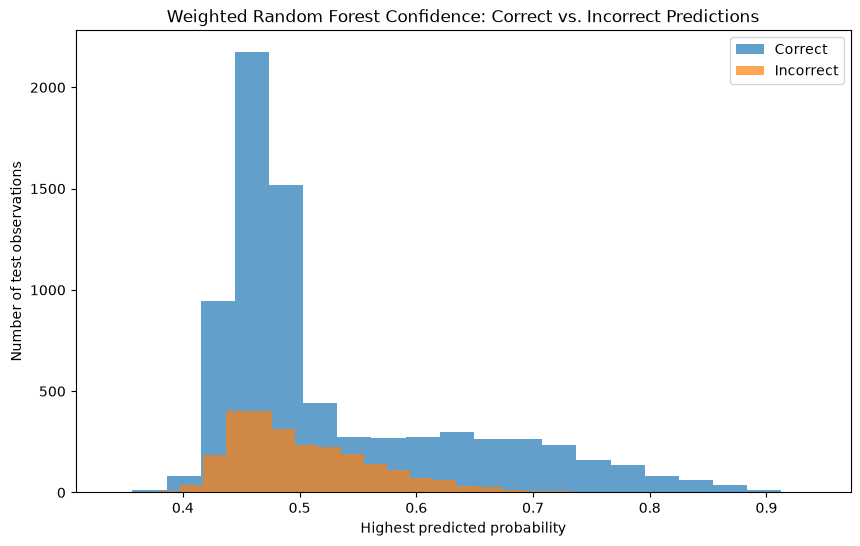

In [99]:
predicted_class = tuned_random_forest.predict(x_test_processed)

correct_prediction = predicted_class == y_test

plt.figure(figsize=(10, 6))

plt.hist(
    max_probabilities[correct_prediction],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    max_probabilities[~correct_prediction],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Highest predicted probability")
plt.ylabel("Number of test observations")
plt.title("Weighted Random Forest Confidence: Correct vs. Incorrect Predictions")
plt.legend()

plt.show()

### XGBoost

In [104]:
xgb_model = xg.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [106]:
label_encoder = sk.preprocessing.LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

print(label_encoder.classes_)

['High' 'Low' 'Moderate']


In [108]:
xgb_model.fit(
    x_train_processed,
    y_train_xgb
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) r

In [109]:
xgb_pred = xgb_model.predict(
    x_test_processed
)

In [110]:
xgb_pred_labels = label_encoder.inverse_transform(
    xgb_pred
)

In [111]:
xgb_accuracy = sk.metrics.accuracy_score(
    y_test,
    xgb_pred_labels
)

xgb_balanced_accuracy = sk.metrics.balanced_accuracy_score(
    y_test,
    xgb_pred_labels
)

print(f"Accuracy: {xgb_accuracy:.3f}")
print(f"Balanced accuracy: {xgb_balanced_accuracy:.3f}")
print()

print(
    sk.metrics.classification_report(
        y_test,
        xgb_pred_labels
    )
)

Accuracy: 0.920
Balanced accuracy: 0.810

              precision    recall  f1-score   support

        High       0.95      0.83      0.89      2422
         Low       0.96      0.61      0.75       703
    Moderate       0.91      0.98      0.94      6875

    accuracy                           0.92     10000
   macro avg       0.94      0.81      0.86     10000
weighted avg       0.92      0.92      0.92     10000



In [112]:
xgb_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    xgb_pred_labels,
    labels=["Low", "Moderate", "High"]
)

print(xgb_confusion_matrix)

[[ 431  272    0]
 [  17 6748  110]
 [   0  400 2022]]


Despite having a slightly lower balanced accuracy relative to the tuned weighted random forest model, the XGBoost model outperformed all other tested models in terms of overall accuracy.
| Model                  |  Accuracy | Balanced Accuracy |  Macro F1 |
| ---------------------- | --------: | ----------------: | --------: |
| Logistic Regression    |     86.0% |             76.2% |     79.0% |
| Random Forest          |     80.9% |             53.3% |     57.0% |
| Weighted Random Forest |     86.6% |             73.7% |     78.3% |
| Tuned Random Forest    |     75.3% |         **84.9%** |     70.0% |
| **XGBoost**            | **92.0%** |             81.0% | **86.0%** |

The confusion matrix also tells us that this model is accurate in predicting moderate-to-high risk cases, but tends to incorrectly elevate low-risk cases:
| Actual → Predicted | Low | Moderate |  High |
| ------------------ | --: | -------: | ----: |
| **Low**            | 431 |      272 |     0 |
| **Moderate**       |  17 |    6,748 |   110 |
| **High**           |   0 |      400 | 2,022 |

Next, the XGBoost model will be cross-validated and tuned using four parameters:
- Number of estimators
- Maximum depth
- Learning rate
- Minimum child weight

In [115]:
xgb_cv = sk.model_selection.cross_val_score(
    xgb_model,
    x_train_processed,
    y_train_xgb,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy",
    n_jobs=-1
)

print("Cross-validation scores:", xgb_cv)
print(f"Mean balanced accuracy: {xgb_cv.mean():.3f}")
print(f"Standard deviation: {xgb_cv.std():.3f}")

Cross-validation scores: [0.80433942 0.80761409 0.81876339 0.80209127 0.81322327]
Mean balanced accuracy: 0.809
Standard deviation: 0.006


In [116]:
xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5]
}

In [117]:
xgb_grid_search = sk.model_selection.GridSearchCV(
    estimator=xg.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(
    x_train_processed,
    y_train_xgb
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 5], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

In [ ]:
print("Best parameters:")
print(xgb_grid_search.best_params_)
print()
print(
    f"Best cross-validation balanced accuracy: "
    f"{xgb_grid_search.best_score_:.3f}"
)

Best parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500}

Best cross-validation balanced accuracy: 0.831


In [119]:
tuned_xgb = xgb_grid_search.best_estimator_

In [120]:
tuned_xgb_pred = tuned_xgb.predict(
    x_test_processed
)

tuned_xgb_pred_labels = label_encoder.inverse_transform(
    tuned_xgb_pred
)

In [121]:
tuned_xgb_accuracy = sk.metrics.accuracy_score(
    y_test,
    tuned_xgb_pred_labels
)

tuned_xgb_balanced_accuracy = sk.metrics.balanced_accuracy_score(
    y_test,
    tuned_xgb_pred_labels
)

print(f"Accuracy: {tuned_xgb_accuracy:.3f}")
print(f"Balanced accuracy: {tuned_xgb_balanced_accuracy:.3f}")
print()

print(
    sk.metrics.classification_report(
        y_test,
        tuned_xgb_pred_labels
    )
)

Accuracy: 0.926
Balanced accuracy: 0.833

              precision    recall  f1-score   support

        High       0.94      0.85      0.89      2422
         Low       0.96      0.67      0.79       703
    Moderate       0.92      0.98      0.95      6875

    accuracy                           0.93     10000
   macro avg       0.94      0.83      0.88     10000
weighted avg       0.93      0.93      0.92     10000



In [122]:
tuned_xgb_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    tuned_xgb_pred_labels,
    labels=["Low", "Moderate", "High"]
)

print(tuned_xgb_confusion_matrix)

[[ 470  233    0]
 [  22 6733  120]
 [   0  364 2058]]


Compared to other models, the tuned XGBoost model outperforms in most categories and nearly matches the balanced accuracy of the tuned random forest model:
| Model                  |  Accuracy | Balanced Accuracy |  Macro F1 |
| ---------------------- | --------: | ----------------: | --------: |
| Logistic Regression    |     86.0% |             76.2% |     79.0% |
| Weighted Random Forest |     86.6% |             73.7% |     78.3% |
| Tuned Random Forest    |     75.3% |         **84.9%** |     70.0% |
| XGBoost                |     92.0% |             81.0% |     86.0% |
| **Tuned XGBoost**      | **92.6%** |         **83.3%** | **88.0%** |
